# Fashion-MNIST DDPM: Training and Denoising Demonstration

This notebook implements a DDPM from scratch in PyTorch and trains it on a deliberately small Fashion-MNIST subset. The main experiment is **reconstruction**: add controlled noise to a real training image and use the learned reverse process to recover an image that closely resembles it.

> A diffusion model cannot promise pixel-perfect reconstruction at every noise level. The reconstruction timestep is intentionally moderate so this notebook shows denoising rather than asking the model to recreate an image from almost pure noise. Training longer generally improves this controlled experiment.

## 1. Imports, configuration, and reproducibility

In [36]:
import random
import math
import os

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.utils import make_grid

# Dataset settings: choose a small subset in the requested 100–500 image range.
NUM_TRAIN_IMAGES = 200
IMAGE_SIZE = 32
CHANNELS = 1
BATCH_SIZE = 32

# DDPM settings. TIMESTEPS remains 1,000 even though reconstruction samples fewer reverse steps.
TIMESTEPS = 1000
BETA_START = 1e-4
BETA_END = 0.02
BASE_CHANNELS = 32
LEARNING_RATE = 2e-4
EPOCHS = 200

# Controlled reconstruction settings. A lower value is easier to reconstruct faithfully.
RECONSTRUCTION_TIMESTEP = 150
RECONSTRUCTION_STEPS = 50
SEED = 42
RESULTS_DIR = '/content/fashion_mnist_ddpm_results'

assert 100 <= NUM_TRAIN_IMAGES <= 500
assert IMAGE_SIZE % 4 == 0
assert 0 < RECONSTRUCTION_TIMESTEP < TIMESTEPS

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
os.makedirs(RESULTS_DIR, exist_ok=True)
print('PyTorch:', torch.__version__)
print('Device:', device)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))


PyTorch: 2.11.0+cu128
Device: cuda
GPU: Tesla T4


## 2. Load a small Fashion-MNIST training set

Fashion-MNIST contains grayscale clothing images. Labels are loaded by the dataset but are **not used by the DDPM**; this remains an unconditional diffusion model. The first run downloads the dataset through torchvision.

In [37]:
fashion_labels = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                  'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

image_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),                    # [1,32,32] in [0,1]
    transforms.Normalize((0.5,), (0.5,)),      # [1,32,32] in [-1,1]
])

full_dataset = datasets.FashionMNIST(
    root='/content/fashion_mnist_data',
    train=True,
    download=True,
    transform=image_transform,
)

# A deterministic subset makes successive runs easier to compare.
subset_indices = list(range(NUM_TRAIN_IMAGES))
train_dataset = Subset(full_dataset, subset_indices)
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
    pin_memory=torch.cuda.is_available(), drop_last=False,
)

print(f'Training images: {len(train_dataset)}')
print(f'Batches per epoch: {len(train_loader)}')


Training images: 200
Batches per epoch: 7


## 3. Inspect the training images

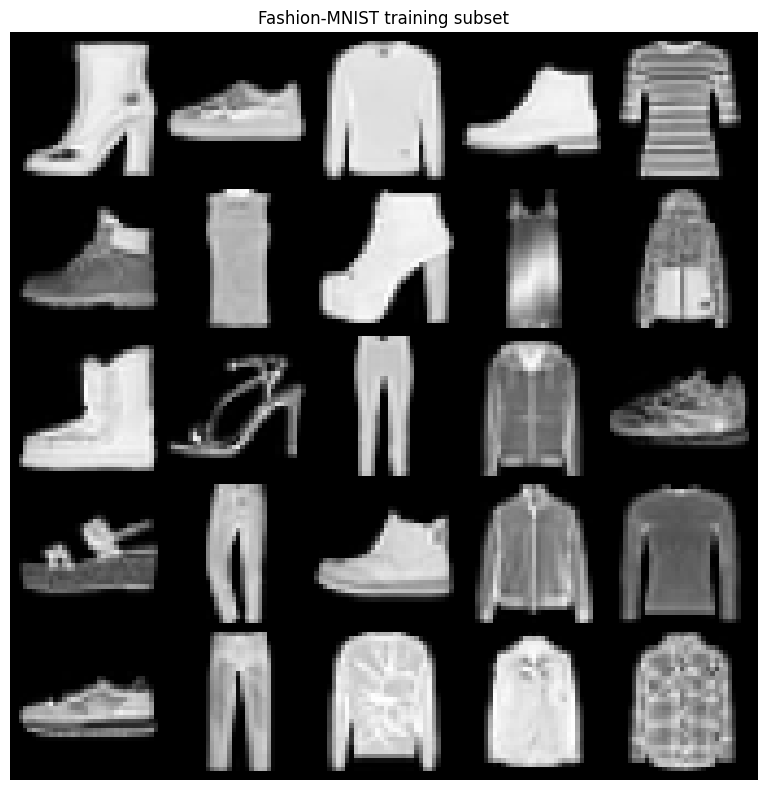

Example labels: ['Ankle boot', 'Sneaker', 'Pullover', 'Ankle boot', 'T-shirt/top', 'Ankle boot', 'T-shirt/top', 'Ankle boot']


In [38]:
def to_display(images):
    """Convert DDPM tensors from [-1,1] back to normal image range [0,1]."""
    return images.detach().cpu().clamp(-1, 1).add(1).div(2)

def show_images(images, title, nrow=5, save_name=None):
    grid = make_grid(to_display(images), nrow=nrow, padding=2)
    plt.figure(figsize=(8, 8))
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap='gray', vmin=0, vmax=1)
    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    if save_name:
        plt.savefig(os.path.join(RESULTS_DIR, save_name), dpi=150, bbox_inches='tight')
    plt.show()

training_batch, training_labels = next(iter(train_loader))
assert training_batch.shape[1:] == (CHANNELS, IMAGE_SIZE, IMAGE_SIZE)
show_images(training_batch[:25], 'Fashion-MNIST training subset', nrow=5, save_name='training_images.png')
print('Example labels:', [fashion_labels[label] for label in training_labels[:8].tolist()])


## 4. DDPM schedule and forward diffusion

The linear beta schedule controls how much noise is added at each step. The forward-process equation is:

`x_t = sqrt(alpha_bar_t) x_0 + sqrt(1-alpha_bar_t) epsilon`, where `epsilon ~ N(0, I)`.

The helper `extract` reshapes a timestep coefficient from `[B]` to `[B,1,1,1]` so it broadcasts correctly over images.

In [39]:
class Diffusion(nn.Module):
    """Precomputes DDPM schedule values and samples the forward process."""
    def __init__(self, timesteps, beta_start, beta_end):
        super().__init__()
        betas = torch.linspace(beta_start, beta_end, timesteps, dtype=torch.float32)
        alphas = 1.0 - betas
        alpha_bars = torch.cumprod(alphas, dim=0)
        alpha_bars_previous = F.pad(alpha_bars[:-1], (1, 0), value=1.0)

        self.register_buffer('betas', betas)
        self.register_buffer('alphas', alphas)
        self.register_buffer('alpha_bars', alpha_bars)
        self.register_buffer('sqrt_alpha_bars', torch.sqrt(alpha_bars))
        self.register_buffer('sqrt_one_minus_alpha_bars', torch.sqrt(1.0 - alpha_bars))
        self.register_buffer('sqrt_recip_alphas', torch.sqrt(1.0 / alphas))

        # Exact q(x_{t-1}|x_t,x_0) variance used by the stochastic DDPM sampler.
        posterior_variance = betas * (1.0 - alpha_bars_previous) / (1.0 - alpha_bars)
        self.register_buffer('posterior_variance', posterior_variance)

    @staticmethod
    def extract(values, t, x_shape):
        assert t.dtype == torch.long and t.ndim == 1
        return values.gather(0, t).reshape(t.shape[0], *((1,) * (len(x_shape) - 1)))

    def q_sample(self, x0, t, noise=None):
        """Return a noisy x_t and the exact Gaussian noise used to construct it."""
        if noise is None:
            noise = torch.randn_like(x0)
        xt = (self.extract(self.sqrt_alpha_bars, t, x0.shape) * x0 +
              self.extract(self.sqrt_one_minus_alpha_bars, t, x0.shape) * noise)
        return xt, noise

diffusion = Diffusion(TIMESTEPS, BETA_START, BETA_END).to(device)
print('Beta schedule:', diffusion.betas[0].item(), 'to', diffusion.betas[-1].item())


Beta schedule: 9.999999747378752e-05 to 0.019999999552965164


## 5. Forward-diffusion visualization

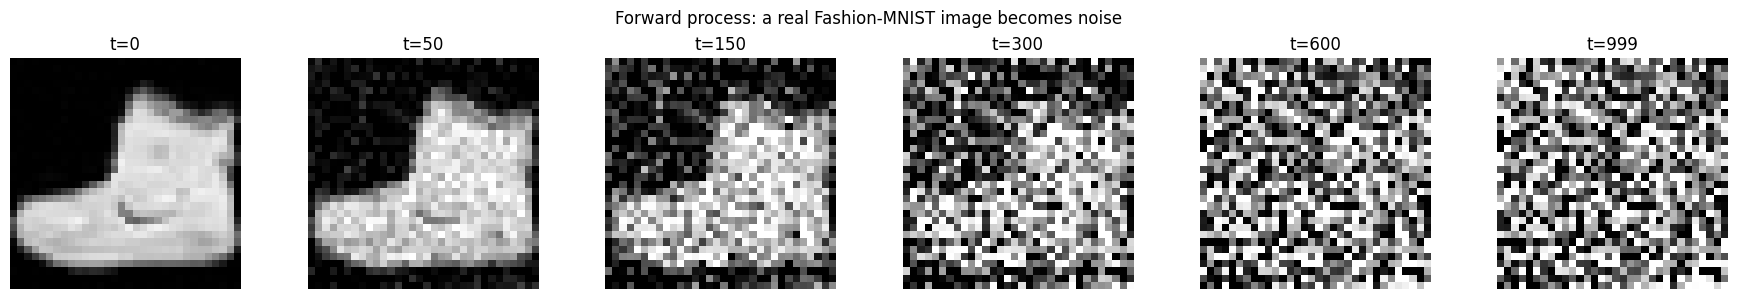

Reference class: Ankle boot


In [40]:
reference_image, reference_label = train_dataset[0]
reference_image = reference_image.unsqueeze(0).to(device)

def show_forward_diffusion(x0):
    times = [0, 50, 150, 300, 600, 999]
    fixed_noise = torch.randn_like(x0)
    fig, axes = plt.subplots(1, len(times), figsize=(18, 3))
    for axis, step in zip(axes, times):
        t = torch.tensor([step], device=device, dtype=torch.long)
        xt, _ = diffusion.q_sample(x0, t, fixed_noise)
        axis.imshow(to_display(xt)[0, 0], cmap='gray', vmin=0, vmax=1)
        axis.set_title(f't={step}')
        axis.axis('off')
    plt.suptitle('Forward process: a real Fashion-MNIST image becomes noise')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'forward_diffusion.png'), dpi=150, bbox_inches='tight')
    plt.show()

show_forward_diffusion(reference_image)
print('Reference class:', fashion_labels[reference_label])


## 6. Timestep embedding, residual blocks, and U-Net

The model predicts the noise in `x_t`, so it must know the current timestep. Sinusoidal embeddings encode `t`, and every residual block receives the resulting time vector. The U-Net goes `32×32 → 16×16 → 8×8 → 16×16 → 32×32`, with skip connections preserving detail.

In [41]:
class SinusoidalTimeEmbedding(nn.Module):
    """Manual sine/cosine embedding for integer diffusion timesteps."""
    def __init__(self, embedding_dim):
        super().__init__()
        assert embedding_dim % 2 == 0
        self.embedding_dim = embedding_dim

    def forward(self, t):
        half = self.embedding_dim // 2
        frequencies = torch.exp(
            -math.log(10000) * torch.arange(half, device=t.device, dtype=torch.float32) / (half - 1)
)
        angles = t.float().unsqueeze(1) * frequencies.unsqueeze(0)
        return torch.cat([angles.sin(), angles.cos()], dim=1)

def group_count(channels):
    return max(group for group in range(1, min(8, channels) + 1) if channels % group == 0)

class ResidualBlock(nn.Module):
    """Convolutional residual block with a broadcast timestep embedding."""
    def __init__(self, in_channels, out_channels, time_dim):
        super().__init__()
        self.norm1 = nn.GroupNorm(group_count(in_channels), in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        self.time_projection = nn.Sequential(nn.SiLU(), nn.Linear(time_dim, out_channels))
        self.norm2 = nn.GroupNorm(group_count(out_channels), out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.shortcut = nn.Identity() if in_channels == out_channels else nn.Conv2d(in_channels, out_channels, 1)

    def forward(self, x, time_embedding):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.time_projection(time_embedding)[:, :, None, None]
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.shortcut(x)

class SmallUNet(nn.Module):
    """Compact timestep-conditioned U-Net for 32x32 Fashion-MNIST images."""
    def __init__(self, channels=1, base_channels=32):
        super().__init__()
        time_dim = base_channels * 4
        self.time_mlp = nn.Sequential(
            SinusoidalTimeEmbedding(base_channels),
            nn.Linear(base_channels, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
)
        self.input_conv = nn.Conv2d(channels, base_channels, 3, padding=1)
        self.enc1 = ResidualBlock(base_channels, base_channels, time_dim)          # 32x32
        self.down1 = nn.Conv2d(base_channels, base_channels * 2, 4, 2, 1)
        self.enc2 = ResidualBlock(base_channels * 2, base_channels * 2, time_dim) # 16x16
        self.down2 = nn.Conv2d(base_channels * 2, base_channels * 4, 4, 2, 1)
        self.mid1 = ResidualBlock(base_channels * 4, base_channels * 4, time_dim) # 8x8
        self.mid2 = ResidualBlock(base_channels * 4, base_channels * 4, time_dim)
        self.up2 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, 4, 2, 1)
        self.dec2 = ResidualBlock(base_channels * 4, base_channels * 2, time_dim)
        self.up1 = nn.ConvTranspose2d(base_channels * 2, base_channels, 4, 2, 1)
        self.dec1 = ResidualBlock(base_channels * 2, base_channels, time_dim)
        self.output = nn.Sequential(
            nn.GroupNorm(group_count(base_channels), base_channels),
            nn.SiLU(),
            nn.Conv2d(base_channels, channels, 3, padding=1),
)

    def forward(self, x, t):
        assert x.ndim == 4 and t.dtype == torch.long and x.shape[0] == t.shape[0]
        time_embedding = self.time_mlp(t)
        x = self.input_conv(x)
        skip1 = self.enc1(x, time_embedding)
        skip2 = self.enc2(self.down1(skip1), time_embedding)
        h = self.mid2(self.mid1(self.down2(skip2), time_embedding), time_embedding)
        h = self.up2(h)
        assert h.shape[-2:] == skip2.shape[-2:]
        h = self.dec2(torch.cat([h, skip2], dim=1), time_embedding)
        h = self.up1(h)
        assert h.shape[-2:] == skip1.shape[-2:]
        h = self.dec1(torch.cat([h, skip1], dim=1), time_embedding)
        return self.output(h)

model = SmallUNet(CHANNELS, BASE_CHANNELS).to(device)
test_x = torch.randn(2, CHANNELS, IMAGE_SIZE, IMAGE_SIZE, device=device)
test_t = torch.randint(0, TIMESTEPS, (2,), device=device, dtype=torch.long)
with torch.no_grad():
    test_output = model(test_x, test_t)
assert test_output.shape == test_x.shape
print('Verified U-Net shape:', tuple(test_output.shape))
print(f'Parameters: {sum(parameter.numel() for parameter in model.parameters()):,}')


Verified U-Net shape: (2, 1, 32, 32)
Parameters: 1,240,609


## 7. DDPM loss and training loop

The target is the exact Gaussian noise used in the forward process. Labels from Fashion-MNIST are unpacked but intentionally ignored.

In [42]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

def ddpm_loss(model, diffusion, x0):
    """Standard epsilon-prediction loss: MSE(epsilon, epsilon_theta(x_t,t))."""
    batch_size = x0.shape[0]
    t = torch.randint(0, TIMESTEPS, (batch_size,), device=x0.device, dtype=torch.long)
    xt, true_noise = diffusion.q_sample(x0, t)
    predicted_noise = model(xt, t)
    return F.mse_loss(predicted_noise, true_noise)

def train_ddpm():
    loss_history = []
    for epoch in range(1, EPOCHS + 1):
        model.train()
        batch_losses = []
        progress = tqdm(train_loader, desc=f'Epoch {epoch}/{EPOCHS}', leave=False)

        for x0, _ in progress:  # The class label is not an input to this unconditional DDPM.
            x0 = x0.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            loss = ddpm_loss(model, diffusion, x0)
            assert not torch.isnan(loss) and not torch.isinf(loss), 'Loss became numerically invalid.'
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            batch_losses.append(loss.item())
            progress.set_postfix(loss=f'{loss.item():.4f}')

        epoch_loss = float(np.mean(batch_losses))
        loss_history.append(epoch_loss)
        print(f'Epoch {epoch:03d}/{EPOCHS} | Noise-prediction MSE: {epoch_loss:.6f}')

    return loss_history


## 8. Train the model

With only 200 images, this is a deliberately small experiment. If reconstruction remains poor, increase `EPOCHS` before changing the 1,000-step training schedule.

Epoch 1/200:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch 001/200 | Noise-prediction MSE: 0.925620


Epoch 2/200:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch 002/200 | Noise-prediction MSE: 0.383400


Epoch 3/200:   0%|          | 0/7 [00:00<?, ?it/s]

...

Epoch 198/200 | Noise-prediction MSE: 0.043256


Epoch 199/200:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch 199/200 | Noise-prediction MSE: 0.035841


Epoch 200/200:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch 200/200 | Noise-prediction MSE: 0.041752


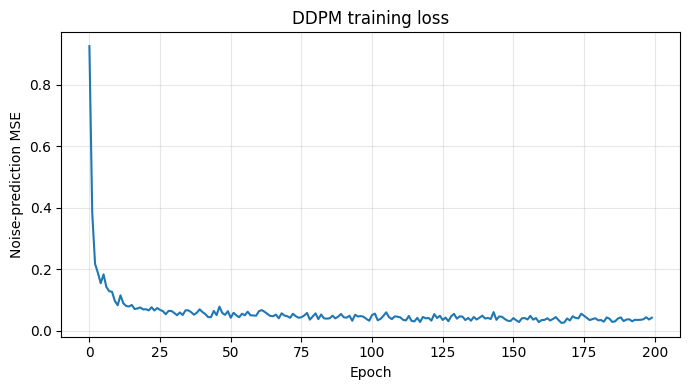

In [43]:
loss_history = train_ddpm()

plt.figure(figsize=(7, 4))
plt.plot(loss_history)
plt.title('DDPM training loss')
plt.xlabel('Epoch')
plt.ylabel('Noise-prediction MSE')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'training_loss.png'), dpi=150)
plt.show()


## 9. Deterministic reverse reconstruction

This section is different from unconditional generation. It starts with a real Fashion-MNIST image after controlled noising at `t=80`, then follows a deterministic DDIM-style reverse path (`eta=0`). No additional random noise is injected during reconstruction, which makes the comparison stable and directly focused on denoising.

For each reverse step, the model predicts epsilon and estimates the clean image using the DDPM forward equation rearranged for `x_0`.

In [44]:
@torch.no_grad()
def ddim_reconstruct(model, diffusion, xt, start_t, sampling_steps=50):
    """Denoise a known x_t deterministically using a subset of the trained 1,000-step schedule."""
    model.eval()
    x = xt.clone()
    sampling_steps = min(sampling_steps, start_t + 1)
    steps = torch.linspace(start_t, 0, sampling_steps, device=device).long()
    steps = torch.unique_consecutive(steps)

    for index, current_step in enumerate(steps):
        t = torch.full((x.shape[0],), int(current_step.item()), device=device, dtype=torch.long)
        predicted_noise = model(x, t)
        alpha_bar_t = diffusion.extract(diffusion.alpha_bars, t, x.shape)
        x0_prediction = (x - torch.sqrt(1.0 - alpha_bar_t) * predicted_noise) / torch.sqrt(alpha_bar_t)

        # The final step returns the estimated clean image.
        if index == len(steps) - 1:
            x = x0_prediction
            break

        previous_step = int(steps[index + 1].item())
        alpha_bar_previous = diffusion.alpha_bars[previous_step].reshape(1, 1, 1, 1)
        # eta=0 DDIM update: deterministic, so no fresh random noise is added here.
        direction = torch.sqrt(1.0 - alpha_bar_previous) * predicted_noise
        x = torch.sqrt(alpha_bar_previous) * x0_prediction + direction

    return x

# Use one actual training image and one known noise tensor for a reproducible reconstruction.
original, original_label = train_dataset[0]
original = original.unsqueeze(0).to(device)
reconstruction_t = torch.tensor([RECONSTRUCTION_TIMESTEP], device=device, dtype=torch.long)
known_noise = torch.randn_like(original)
noisy_image, _ = diffusion.q_sample(original, reconstruction_t, known_noise)
reconstructed = ddim_reconstruct(model, diffusion, noisy_image, RECONSTRUCTION_TIMESTEP, RECONSTRUCTION_STEPS)

# Image metrics quantify closeness but should be considered alongside the visual comparison.
mae = F.l1_loss(reconstructed, original).item()
mse = F.mse_loss(reconstructed, original).item()
psnr = 10 * math.log10(4.0 / max(mse, 1e-12))  # Model-space peak-to-peak range is 2, hence peak^2=4.
print(f'Reconstruction MAE: {mae:.4f}')
print(f'Reconstruction PSNR: {psnr:.2f} dB')
print('Reference class:', fashion_labels[original_label])


Reconstruction MAE: 0.0902
Reconstruction PSNR: 23.02 dB
Reference class: Ankle boot


## 10. Original → noisy → denoised comparison

The middle image is created by adding Gaussian noise to a real Fashion-MNIST training image at timestep `t = 150`.

The final image is produced by the trained DDPM through a deterministic reverse denoising process using 50 sampling steps. At timestep 150, the image is visibly corrupted but still retains useful structure from the original item.

This makes the experiment a practical test of whether the model has learned to remove moderate Gaussian noise while preserving the main clothing shape and outline.



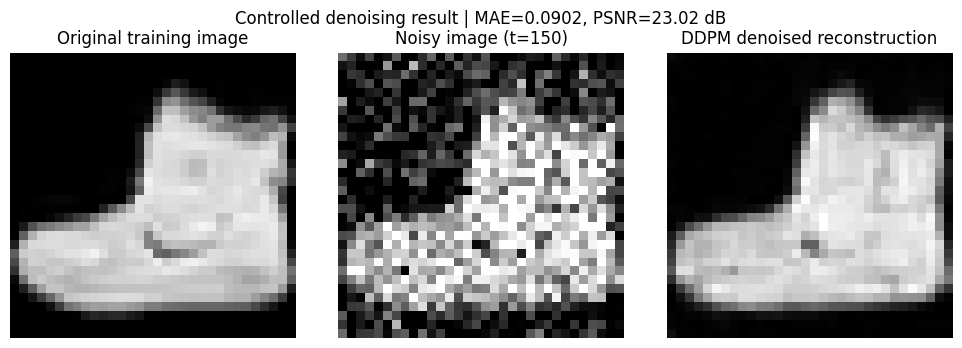

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
for axis, image, title in zip(
    axes,
    [original, noisy_image, reconstructed],
    ['Original training image', f'Noisy image (t={RECONSTRUCTION_TIMESTEP})', 'DDPM denoised reconstruction'],
):
    axis.imshow(to_display(image)[0, 0], cmap='gray', vmin=0, vmax=1)
    axis.set_title(title)
    axis.axis('off')

plt.suptitle(f'Controlled denoising result | MAE={mae:.4f}, PSNR={psnr:.2f} dB')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'original_noisy_denoised.png'), dpi=180, bbox_inches='tight')
plt.show()


## 11. Reconstruct several training images

A successful model should denoise more than one selected image. This cell runs the same controlled experiment on five samples from the training subset.

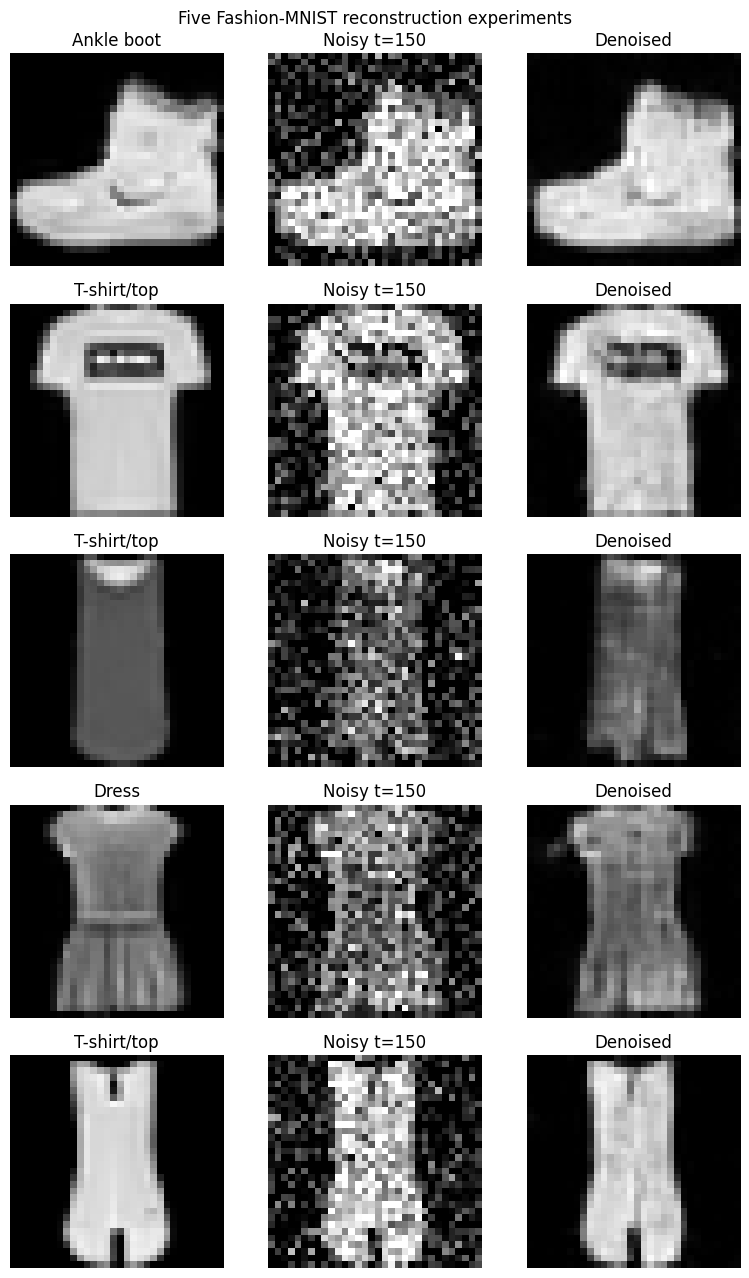

In [46]:
selected_indices = [0, 1, 2, 3, 4]
fig, axes = plt.subplots(len(selected_indices), 3, figsize=(8, 2.6 * len(selected_indices)))

for row, index in enumerate(selected_indices):
    x0, label = train_dataset[index]
    x0 = x0.unsqueeze(0).to(device)
    t = torch.tensor([RECONSTRUCTION_TIMESTEP], device=device, dtype=torch.long)
    xt, _ = diffusion.q_sample(x0, t, torch.randn_like(x0))
    x_reconstructed = ddim_reconstruct(model, diffusion, xt, RECONSTRUCTION_TIMESTEP, RECONSTRUCTION_STEPS)

    for column, (image, title) in enumerate([
        (x0, fashion_labels[label]),
        (xt, f'Noisy t={RECONSTRUCTION_TIMESTEP}'),
        (x_reconstructed, 'Denoised'),
    ]):
        axes[row, column].imshow(to_display(image)[0, 0], cmap='gray', vmin=0, vmax=1)
        axes[row, column].set_title(title)
        axes[row, column].axis('off')

plt.suptitle('Five Fashion-MNIST reconstruction experiments')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'multiple_reconstructions.png'), dpi=180, bbox_inches='tight')
plt.show()


## 12. Checkpoint saving and loading

Save the trained state after a run. In Colab, copy the checkpoint to Google Drive if it needs to survive a runtime reset.

In [47]:
checkpoint_path = os.path.join(RESULTS_DIR, 'fashion_mnist_ddpm_checkpoint.pt')

def save_checkpoint(path, epoch, history):
    torch.save({
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'epoch': epoch,
        'loss_history': history,
        'config': {
            'num_train_images': NUM_TRAIN_IMAGES,
            'image_size': IMAGE_SIZE,
            'timesteps': TIMESTEPS,
            'base_channels': BASE_CHANNELS,
        },
    }, path)

def load_checkpoint(path):
    checkpoint = torch.load(path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    print(f"Loaded checkpoint from epoch {checkpoint['epoch']}")
    return checkpoint

save_checkpoint(checkpoint_path, EPOCHS, loss_history)
print('Checkpoint saved to:', checkpoint_path)

# To resume later: checkpoint = load_checkpoint(checkpoint_path)


Checkpoint saved to: /content/fashion_mnist_ddpm_results/fashion_mnist_ddpm_checkpoint.pt


## Implementation notes

- The training objective is standard DDPM epsilon prediction with a 1,000-step linear beta schedule.
- The reconstruction begins from a real image after forward noising; this is not the same task as generating an image from pure Gaussian noise.
- Deterministic reverse reconstruction is used here so the visual result reflects the learned denoising ability rather than fresh random noise at each step.
- For closer reconstructions, lower `RECONSTRUCTION_TIMESTEP` or train longer. For a more challenging demonstration, raise it gradually and compare the saved results.